# Portuguese Bank Marketing Dataset - Binary Classification ML Project

This notebook implements an end-to-end Machine Learning pipeline to predict whether a customer will subscribe to a term deposit (`yes` or `no`) based on the UCI Portuguese Bank Marketing dataset.

### Project Roadmap
1. **Import Libraries & Settings**
2. **Load Dataset**
3. **Exploratory Data Analysis (EDA)**
4. **Feature Engineering**
5. **Preprocessing**
6. **Model Training & Comparison** (7 models)
7. **Evaluation & Analysis** (ROC/PR curves, Feature Importance, Threshold Tuning)
8. **Save Final Model Pipeline**


## 1. Import Libraries & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

# Set styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

warnings.filterwarnings('ignore')


## 2. Load Dataset

In [2]:
!pip install -q gdown
import gdown
gdown.download(
    "https://drive.google.com/uc?id=1xrA9UDM2Fw3aYnfW1_TLSegfRXSWcWw_",
    "bank-full.csv",
    quiet=False
)

# Load the dataset
# Note: bank-full.csv is actually the bank-additional-full.csv (41,188 x 21) containing macroeconomic features
df = pd.read_csv("bank-full.csv", sep=";")
print(f"Dataset shape: {df.shape}")
df.head()


[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Downloading...
From: https://drive.google.com/uc?id=1xrA9UDM2Fw3aYnfW1_TLSegfRXSWcWw_
To: C:\Users\sures\Downloads\ML-CaPsule\Projects\Portuguese_Bank_Marketing\bank-full.csv


  0%|          | 0.00/4.61M [00:00<?, ?B/s]

 11%|█▏        | 524k/4.61M [00:00<00:04, 931kB/s]

 23%|██▎       | 1.05M/4.61M [00:01<00:03, 982kB/s]

...

 91%|█████████ | 4.19M/4.61M [00:03<00:00, 1.55MB/s]

100%|██████████| 4.61M/4.61M [00:03<00:00, 1.53MB/s]

100%|██████████| 4.61M/4.61M [00:03<00:00, 1.31MB/s]

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Imbalance Analysis of Target Variable

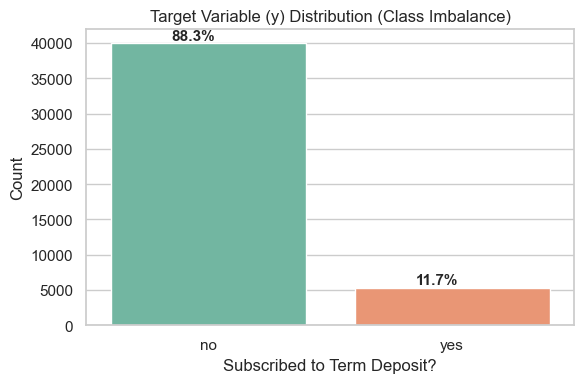

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Target Variable (y) Distribution (Class Imbalance)')
plt.xlabel('Subscribed to Term Deposit?')
plt.ylabel('Count')

# Calculate percentages
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 500
    plt.gca().annotate(percentage, (x, y), fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=300)
plt.show()


### 3.2 Age Distribution and Subscription Rate by Age Group

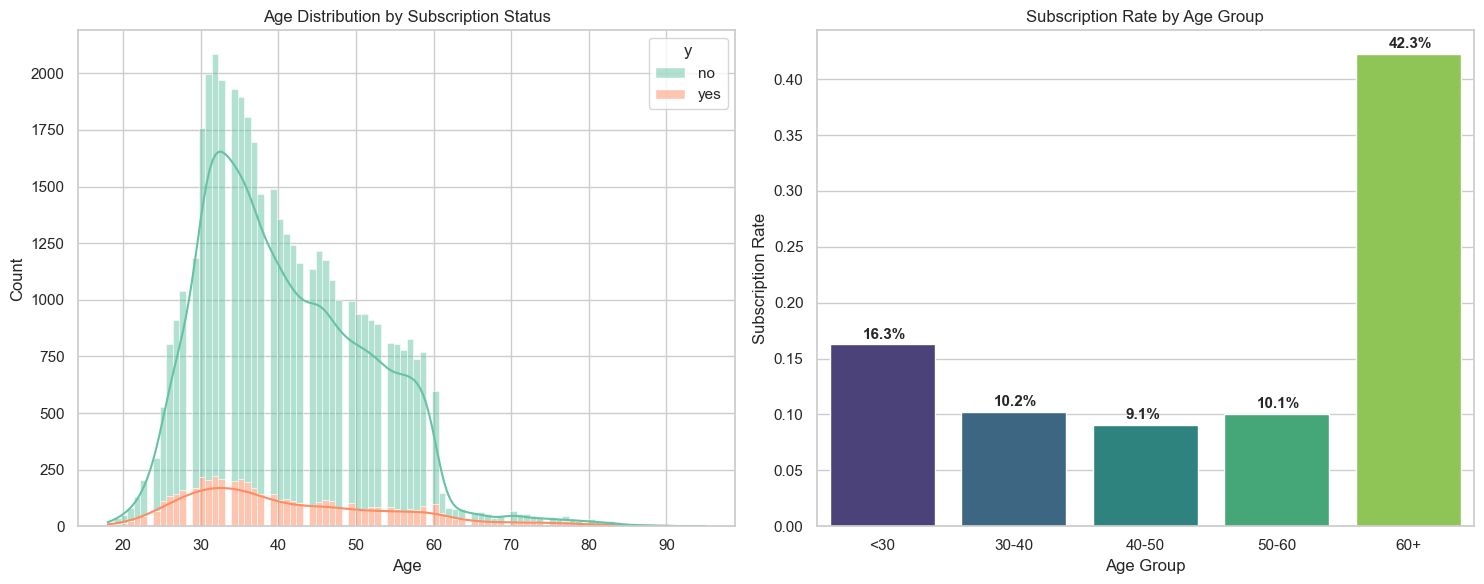

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram with KDE
sns.histplot(data=df, x='age', hue='y', multiple='stack', kde=True, ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Subscription Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Subscription rate by age group
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100], labels=['<30', '30-40', '40-50', '50-60', '60+'])
age_sub_rate = df.groupby('age_group', observed=False)['y'].apply(lambda x: (x == 'yes').mean()).reset_index()
sns.barplot(data=age_sub_rate, x='age_group', y='y', ax=axes[1], palette='viridis')
axes[1].set_title('Subscription Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Subscription Rate')

# Annotate values
for p in axes[1].patches:
    val = f'{100 * p.get_height():.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 0.005
    axes[1].annotate(val, (x, y), fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('age_analysis.png', dpi=300)
plt.show()


### 3.3 Campaign Contacts vs. Subscription Rate (Diminishing Returns)

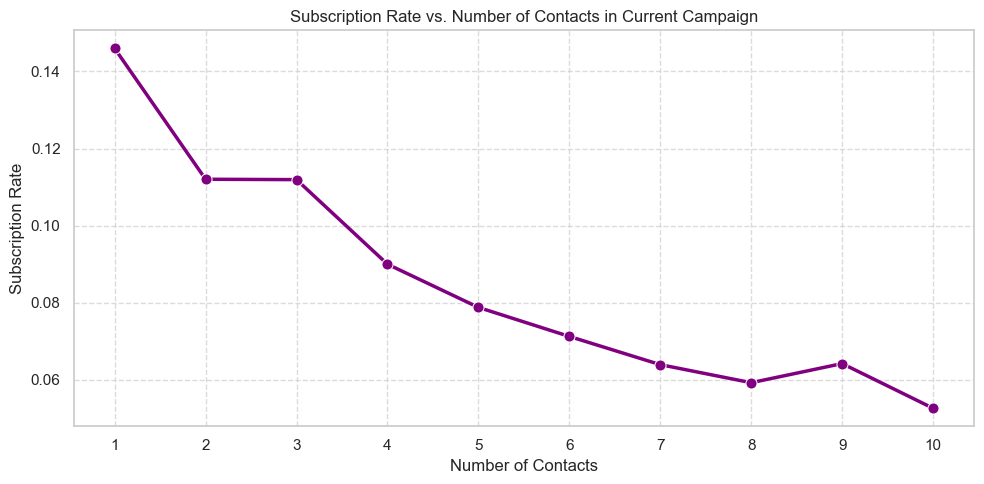

In [5]:
plt.figure(figsize=(10, 5))
campaign_sub = df.groupby('campaign')['y'].apply(lambda x: (x == 'yes').mean()).reset_index()

# Plot contacts <= 10 to see trend clearly (most data lies here)
sns.lineplot(data=campaign_sub[campaign_sub['campaign'] <= 10], x='campaign', y='y', marker='o', color='purple', linewidth=2.5, markersize=8)
plt.title('Subscription Rate vs. Number of Contacts in Current Campaign')
plt.xlabel('Number of Contacts')
plt.ylabel('Subscription Rate')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('campaign_analysis.png', dpi=300)
plt.show()


### 3.4 Previous Campaign Outcome vs. Subscription Rate

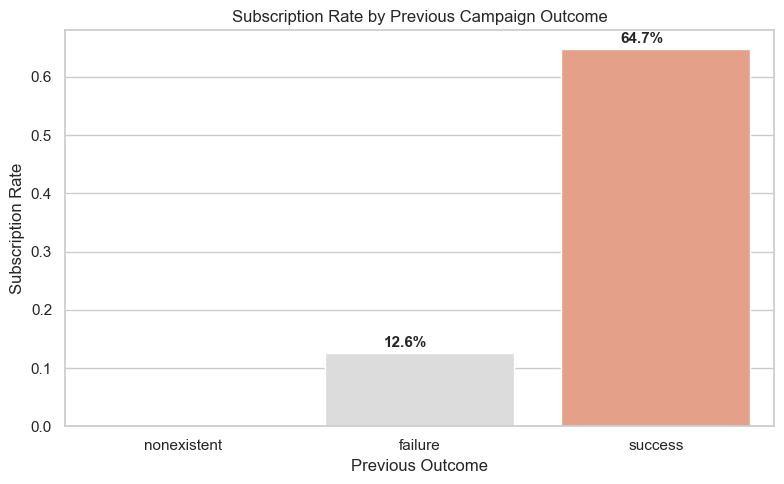

In [6]:
plt.figure(figsize=(8, 5))
poutcome_sub = df.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean()).reset_index()
sns.barplot(data=poutcome_sub, x='poutcome', y='y', palette='coolwarm', order=['nonexistent', 'failure', 'success'])
plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Outcome')
plt.ylabel('Subscription Rate')

for p in plt.gca().patches:
    val = f'{100 * p.get_height():.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 0.01
    plt.gca().annotate(val, (x, y), fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('poutcome_analysis.png', dpi=300)
plt.show()


### 3.5 Contact Method Comparison

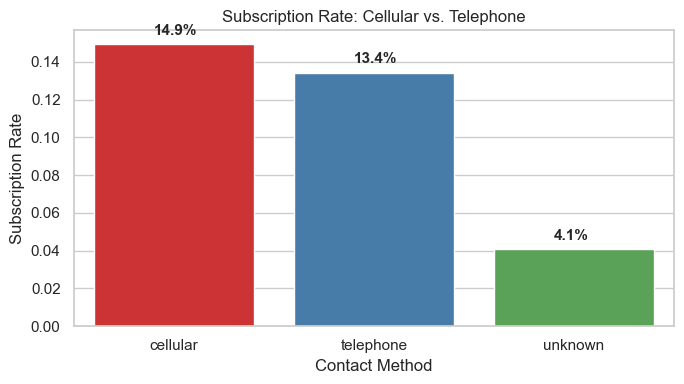

In [7]:
plt.figure(figsize=(7, 4))
contact_sub = df.groupby('contact')['y'].apply(lambda x: (x == 'yes').mean()).reset_index()
sns.barplot(data=contact_sub, x='contact', y='y', palette='Set1')
plt.title('Subscription Rate: Cellular vs. Telephone')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate')

for p in plt.gca().patches:
    val = f'{100 * p.get_height():.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 0.005
    plt.gca().annotate(val, (x, y), fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('contact_analysis.png', dpi=300)
plt.show()


### 3.6 Monthly Subscription Trends

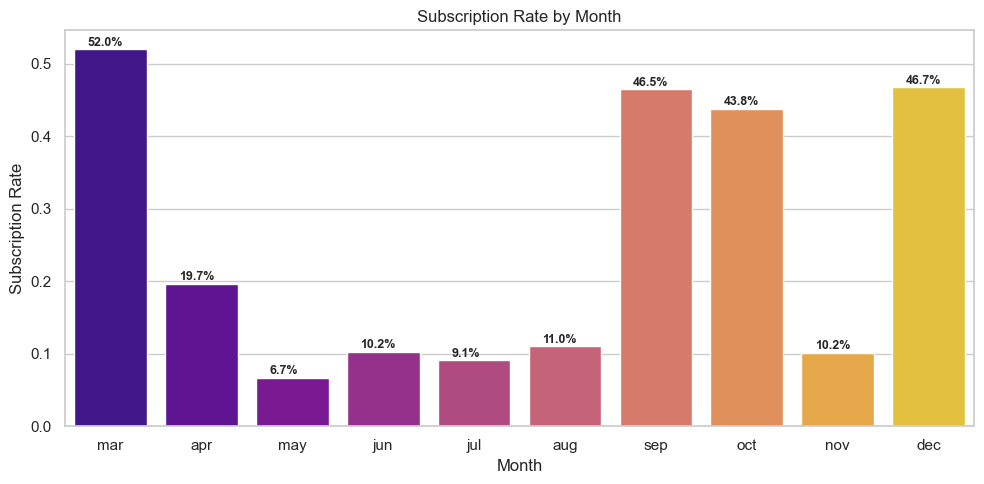

In [8]:
plt.figure(figsize=(10, 5))
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = df['month'].str.lower()
month_sub = df.groupby('month', observed=False)['y'].apply(lambda x: (x == 'yes').mean()).reindex(month_order).reset_index()

sns.barplot(data=month_sub, x='month', y='y', palette='plasma')
plt.title('Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate')

for p in plt.gca().patches:
    if p.get_height() > 0:
        val = f'{100 * p.get_height():.1f}%'
        x = p.get_x() + p.get_width() / 2 - 0.25
        y = p.get_height() + 0.005
        plt.gca().annotate(val, (x, y), fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=300)
plt.show()


### 3.7 Correlation Heatmap of Numerical and Economic Features

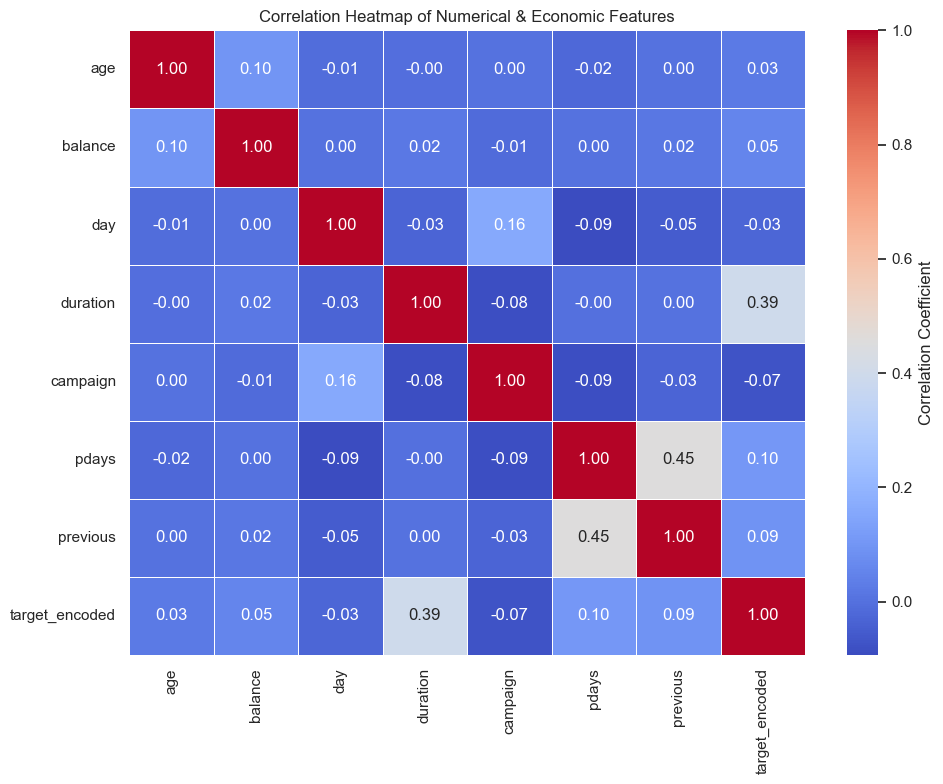

In [9]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_corr = df.copy()
df_corr['target_encoded'] = (df_corr['y'] == 'yes').astype(int)

corr_matrix = df_corr[numeric_cols + ['target_encoded']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Numerical & Economic Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()


### 3.8 Boxplots for Outlier Detection

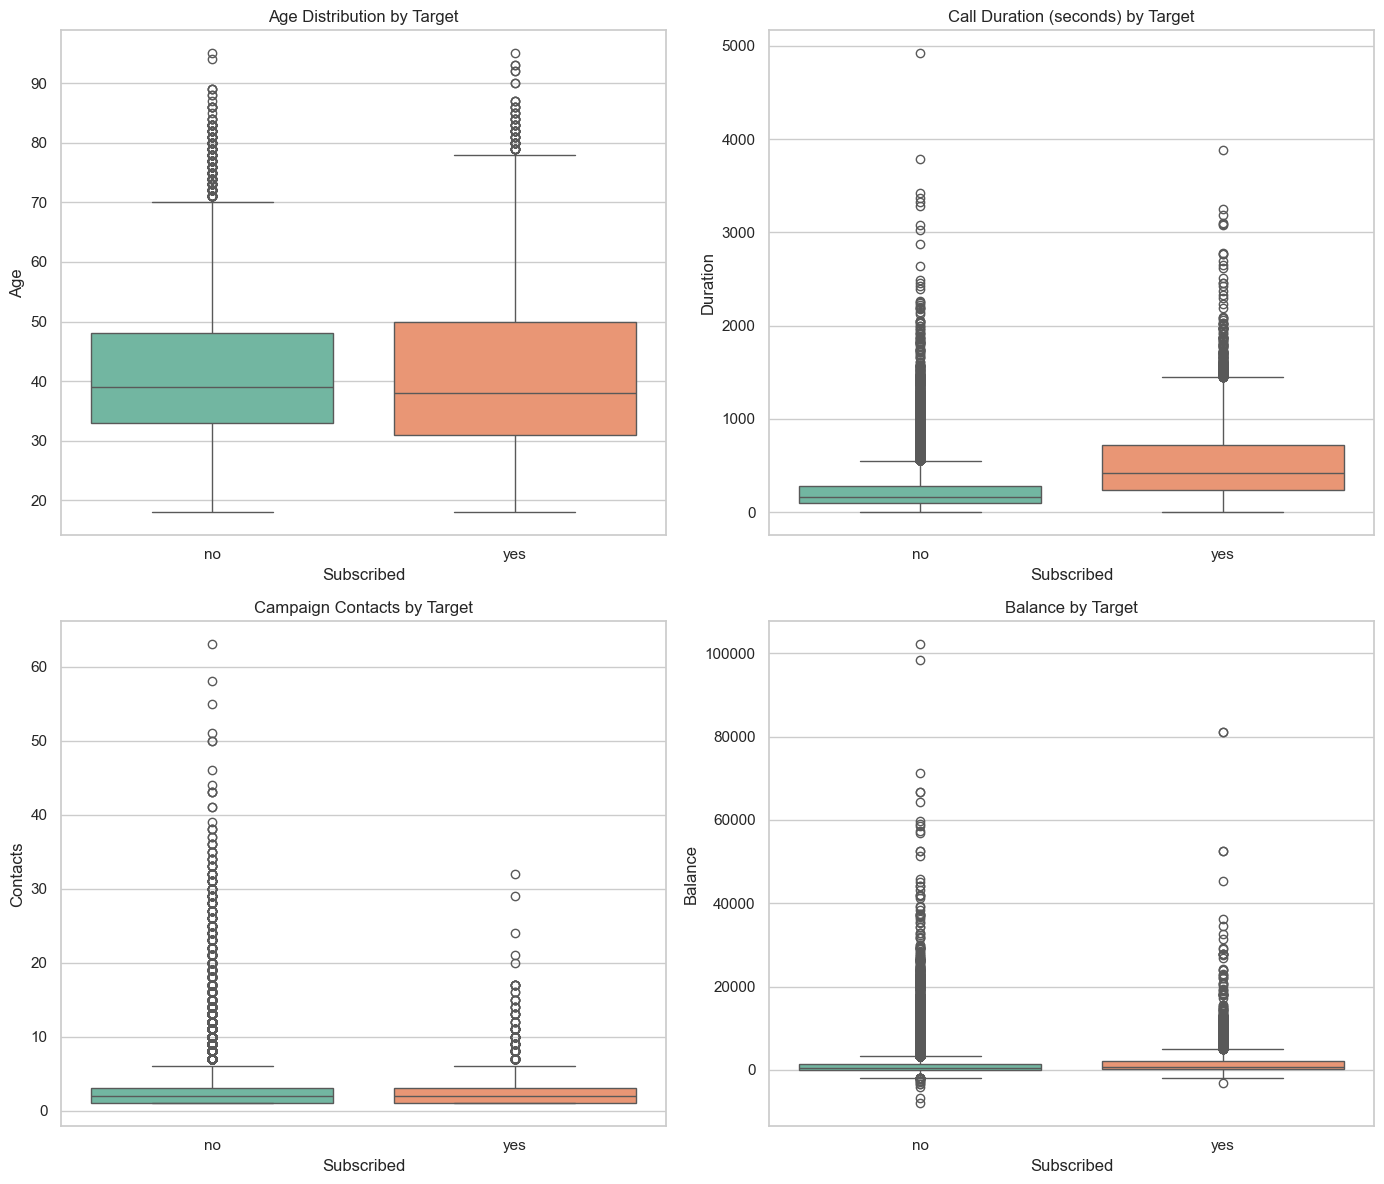

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.boxplot(data=df, y='age', x='y', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Age Distribution by Target')
axes[0, 0].set_xlabel('Subscribed')
axes[0, 0].set_ylabel('Age')

sns.boxplot(data=df, y='duration', x='y', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Call Duration (seconds) by Target')
axes[0, 1].set_xlabel('Subscribed')
axes[0, 1].set_ylabel('Duration')

sns.boxplot(data=df, y='campaign', x='y', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Campaign Contacts by Target')
axes[1, 0].set_xlabel('Subscribed')
axes[1, 0].set_ylabel('Contacts')

sns.boxplot(data=df, y='balance', x='y', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Balance by Target')
axes[1, 1].set_xlabel('Subscribed')
axes[1, 1].set_ylabel('Balance')

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=300)
plt.show()


## 4. Feature Engineering

In [11]:
# 1. previously_contacted: derived from pdays (999 -> never contacted)
df['previously_contacted'] = (df['pdays'] != 999).astype(int)

# 2. campaign_log: log transformation to reduce skewness
df['campaign_log'] = np.log1p(df['campaign'])

# 3. campaign_level: bucketed campaign contacts
def bucket_campaign(c):
    if c <= 2: return 'low'
    elif c <= 5: return 'medium'
    else: return 'high'
df['campaign_level'] = df['campaign'].apply(bucket_campaign)

# 4. previous_campaign_interaction: interaction feature
# Multiplying the number of previous contacts by the previously contacted binary flag
df['previous_campaign_interaction'] = df['previous'] * df['previously_contacted']

print("Engineered features preview:")
df[['pdays', 'previously_contacted', 'campaign', 'campaign_log', 'campaign_level', 'previous', 'previous_campaign_interaction']].head()


Engineered features preview:


,pdays,previously_contacted,campaign,campaign_log,campaign_level,previous,previous_campaign_interaction
0,-1,1,1,0.693147,low,0,0
1,-1,1,1,0.693147,low,0,0
2,-1,1,1,0.693147,low,0,0
3,-1,1,1,0.693147,low,0,0
4,-1,1,1,0.693147,low,0,0


## 5. Preprocessing & Splitting Data

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Split features and target
# We drop age_group (EDA column), 'y' (target), and the original 'campaign' column to avoid multicollinearity
X = df.drop(columns=['y', 'age_group', 'campaign'])
y = (df['y'] == 'yes').astype(int)

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# Define the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

# Split into train and test sets (stratified to handle class imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Numerical features: ['age', 'balance', 'day', 'duration', 'pdays', 'previous', 'previously_contacted', 'campaign_log', 'previous_campaign_interaction']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'campaign_level']

Training set shape: (36168, 19)
Test set shape: (9043, 19)


## 6. Train Models & Compare

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Fit the preprocessor on training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Initialize 7 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(kernel='linear', max_iter=2000, probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='logloss', random_state=42, n_jobs=-1)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_preprocessed, y_train)
    trained_models[name] = model
    
    # Get predictions & probabilities
    y_pred = model.predict(X_test_preprocessed)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_preprocessed)[:, 1]
    else:
        y_prob = y_pred
        
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

# Compare results
df_results = pd.DataFrame(results)
print(df_results.sort_values(by='ROC-AUC', ascending=False).to_string(index=False))


Training Logistic Regression...


Training K-Nearest Neighbors...


Training Support Vector Machine...


Training Decision Tree...


Training Random Forest...


Training Gradient Boosting...


Training XGBoost...


                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
               XGBoost  0.908437   0.662890 0.442344  0.530612 0.932985
     Gradient Boosting  0.908327   0.653691 0.460302  0.540211 0.929423
         Random Forest  0.900697   0.732558 0.238185  0.359486 0.923209
   Logistic Regression  0.901692   0.649558 0.346881  0.452249 0.906480
   K-Nearest Neighbors  0.895610   0.595000 0.337429  0.430639 0.834111
         Decision Tree  0.898817   0.603774 0.393195  0.476245 0.832682
Support Vector Machine  0.533230   0.147537 0.625709  0.238774 0.614335


## 7. Evaluation & Detailed Analysis

### 7.1 Final Model Selection: Gradient Boosting

Classification Report:


              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.46      0.54      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.71      0.74      9043
weighted avg       0.90      0.91      0.90      9043

Confusion Matrix:


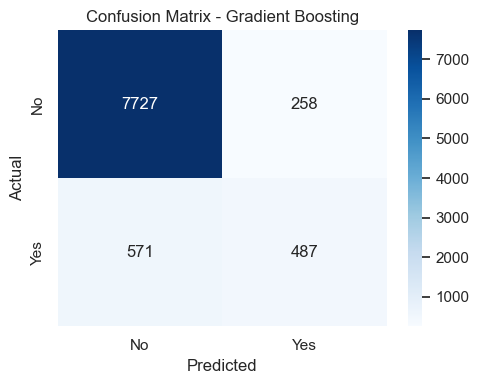

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve

final_model = trained_models['Gradient Boosting']
y_pred_gb = final_model.predict(X_test_preprocessed)
y_prob_gb = final_model.predict_proba(X_test_preprocessed)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_gb))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()


### 7.2 ROC & Precision-Recall Curves

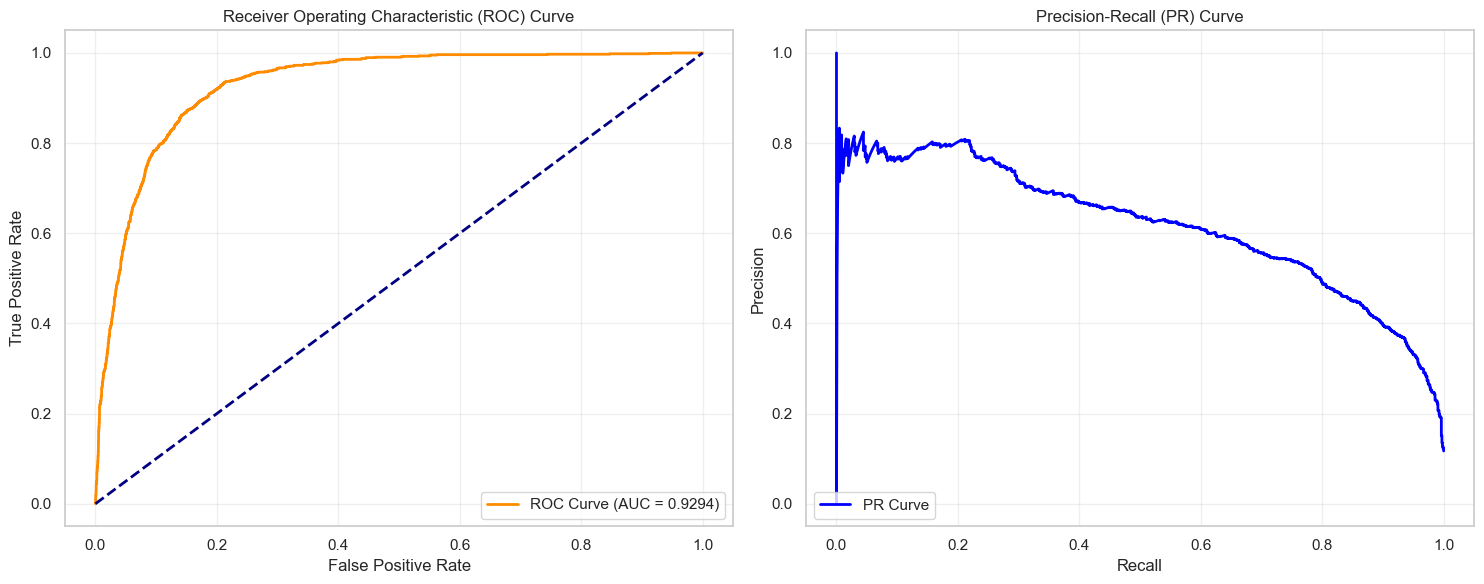

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_gb)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob_gb):.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_gb)
axes[1].plot(recall_curve, precision_curve, color='blue', lw=2, label='PR Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curve')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_curves.png', dpi=300)
plt.show()


### 7.3 Feature Importance Analysis

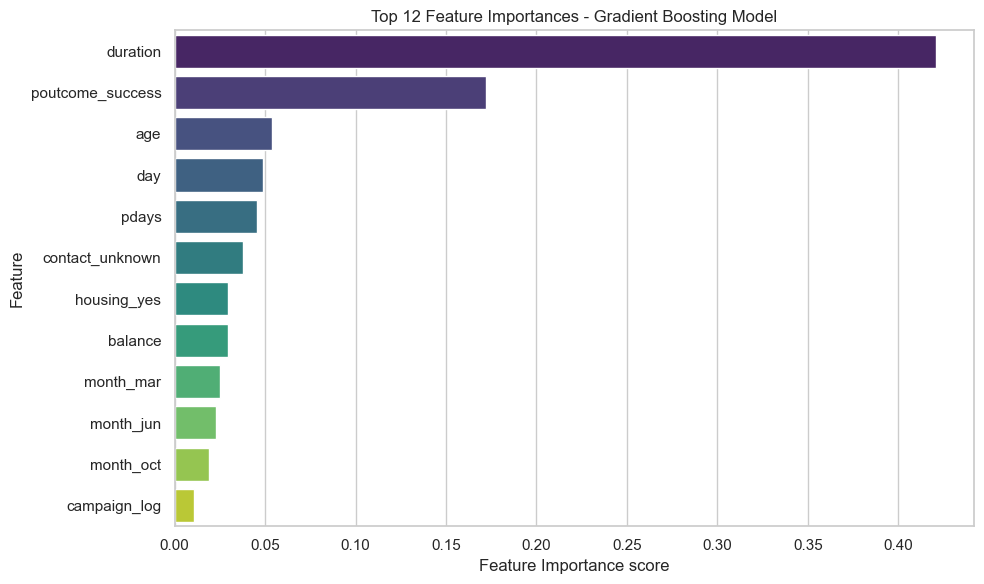

In [16]:
# Extract feature names from ColumnTransformer
feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__')[1] for name in feature_names]

importances = final_model.feature_importances_
df_importance = pd.DataFrame({'Feature': clean_feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 12 Feature Importances - Gradient Boosting Model')
plt.xlabel('Feature Importance score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()


### 7.4 Threshold Tuning & Trade-off Analysis

In [17]:
thresholds = [0.5, 0.3, 0.2]
tuning_results = []

for t in thresholds:
    y_pred_t = (y_prob_gb >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    tuning_results.append({
        'Threshold': t,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_tuning = pd.DataFrame(tuning_results)
print(df_tuning.to_string(index=False))


 Threshold  Accuracy  Precision   Recall  F1-Score
       0.5  0.908327   0.653691 0.460302  0.540211
       0.3  0.900254   0.560092 0.687146  0.617148
       0.2  0.885879   0.507908 0.789225  0.618061


## 8. Save Model Pipeline

In [18]:
from sklearn.pipeline import Pipeline

# Build a comprehensive pipeline that includes the preprocessor AND the model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])

# Ensure directories exist
os.makedirs('model', exist_ok=True)

# Save the pipeline via joblib
joblib.dump(full_pipeline, "model/gradient_boosting_model.pkl")
print("Full pipeline successfully saved to 'model/gradient_boosting_model.pkl'!")

# Verify loading works
loaded_pipeline = joblib.load("model/gradient_boosting_model.pkl")
test_predictions = loaded_pipeline.predict(X_test)
print(f"Loaded pipeline model test accuracy: {accuracy_score(y_test, test_predictions):.4f}")


Full pipeline successfully saved to 'model/gradient_boosting_model.pkl'!


Loaded pipeline model test accuracy: 0.9083
